In [1]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_m_flan_t5_xl_full_few_shot_1_examples_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_m_flan_t5_xl_full_few_shot_1_examples_neutral.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_m_flan_t5_xl_full_few_shot_1_examples_contradiction.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_m_flan_t5_xl_full_few_shot_3_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_m_flan_t5_xl_full_few_shot_5_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_m_flan_t5_xl_full_few_shot_10_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_m_flan_t5_xl_full_few_shot_15_examples.pt
Checkpoint found.


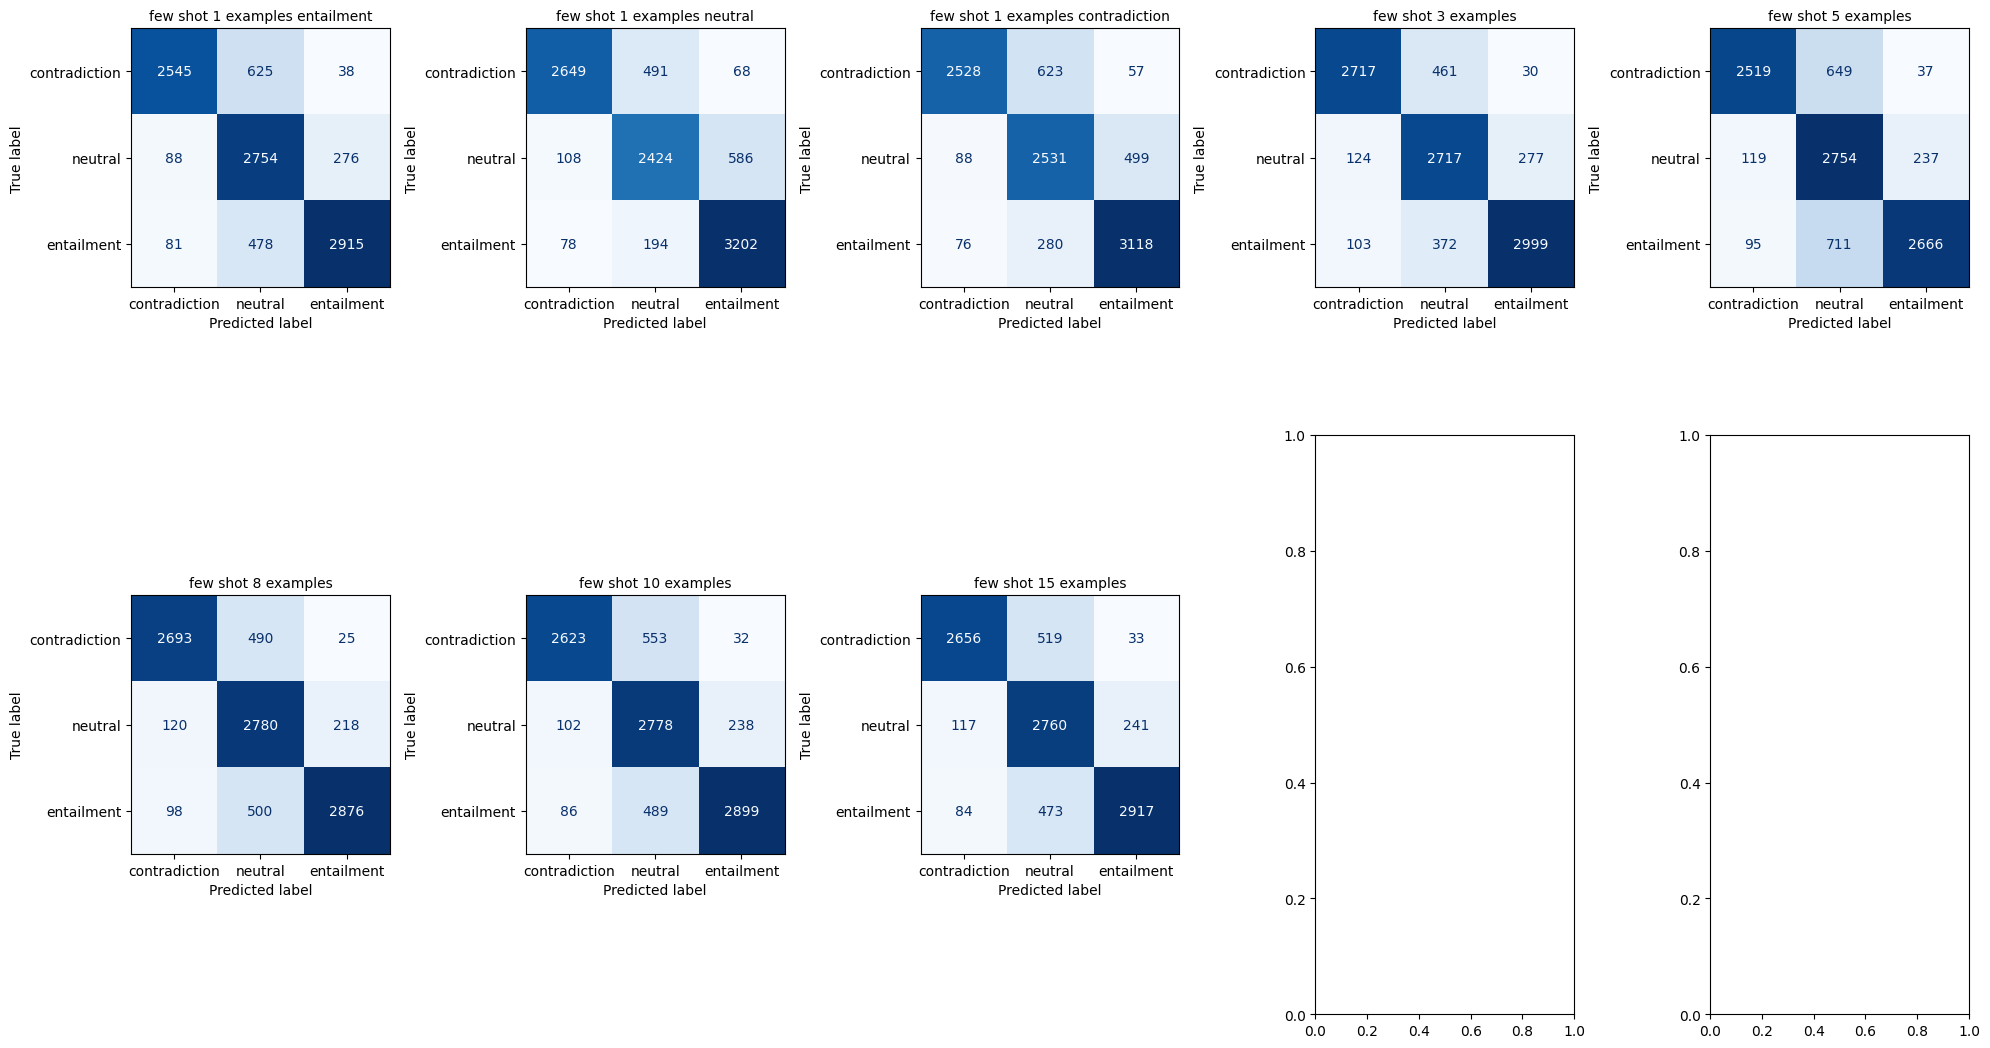

In [4]:
import matplotlib.pyplot as plt

training_modes = [
    # 'zero shot chat template',
    'few shot 1 examples entailment',
    'few shot 1 examples neutral',
    'few shot 1 examples contradiction',
    'few shot 3 examples',
    'few shot 5 examples',
    'few shot 8 examples',
    'few shot 10 examples',
    'few shot 15 examples'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

idx = 0
for mode in training_modes:
    global_params = {
            'dataset_type': 'mnli_m',
            'quantization': 'full',
            'training_mode': mode,
            'model_id': 'google/flan-t5-xl'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

    idx += 1


plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
labels = [
    # "0 examples",
    "1 example (entailment)",
    "1 example (neutral)",
    "1 example (contradiction)",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
    "F1": f1s,
    "MCC": mccs,
    "Kappa": kappas},
    index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
1 example (entailment),0.8382,0.8515,0.8386,0.8396,0.7625,0.7575
1 example (neutral),0.8444,0.8482,0.8416,0.8430,0.7677,0.7660
1 example (contradiction),0.8344,0.8416,0.8324,0.8340,0.7536,0.7512
3 examples,0.8605,0.8651,0.8605,0.8610,0.7926,0.7908
5 examples,0.8101,0.4996,0.4872,0.4882,0.7246,0.7161
8 examples,0.8519,0.8615,0.8530,0.8533,0.7821,0.7782
10 examples,0.8469,0.8584,0.8477,0.8484,0.7752,0.7707
15 examples,0.8503,0.8598,0.8509,0.8516,0.7794,0.7757


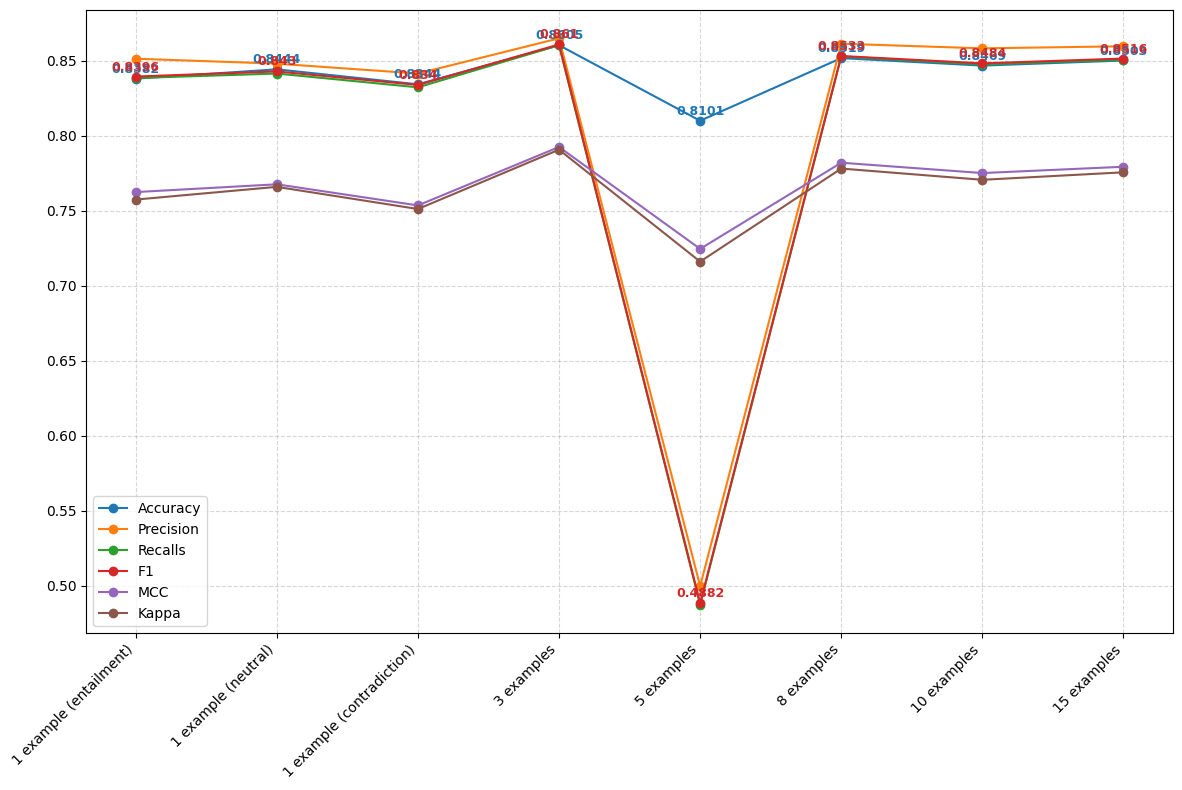

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_1_m_examples_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_1_m_examples_neutral.pt
Checkpoint found.


/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_1_m_examples_contradiction.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_1_mm_examples_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_1_mm_examples_neutral.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_1_mm_examples_contradiction.pt
Checkpoint found.


/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_3_mm_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_5_mm_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_8_mm_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_10_mm_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Flan_T5_XL/Results/checkpoint_mnli_mm_flan_t5_xl_full_few_shot_15_mm_examples.pt
Checkpoint found.


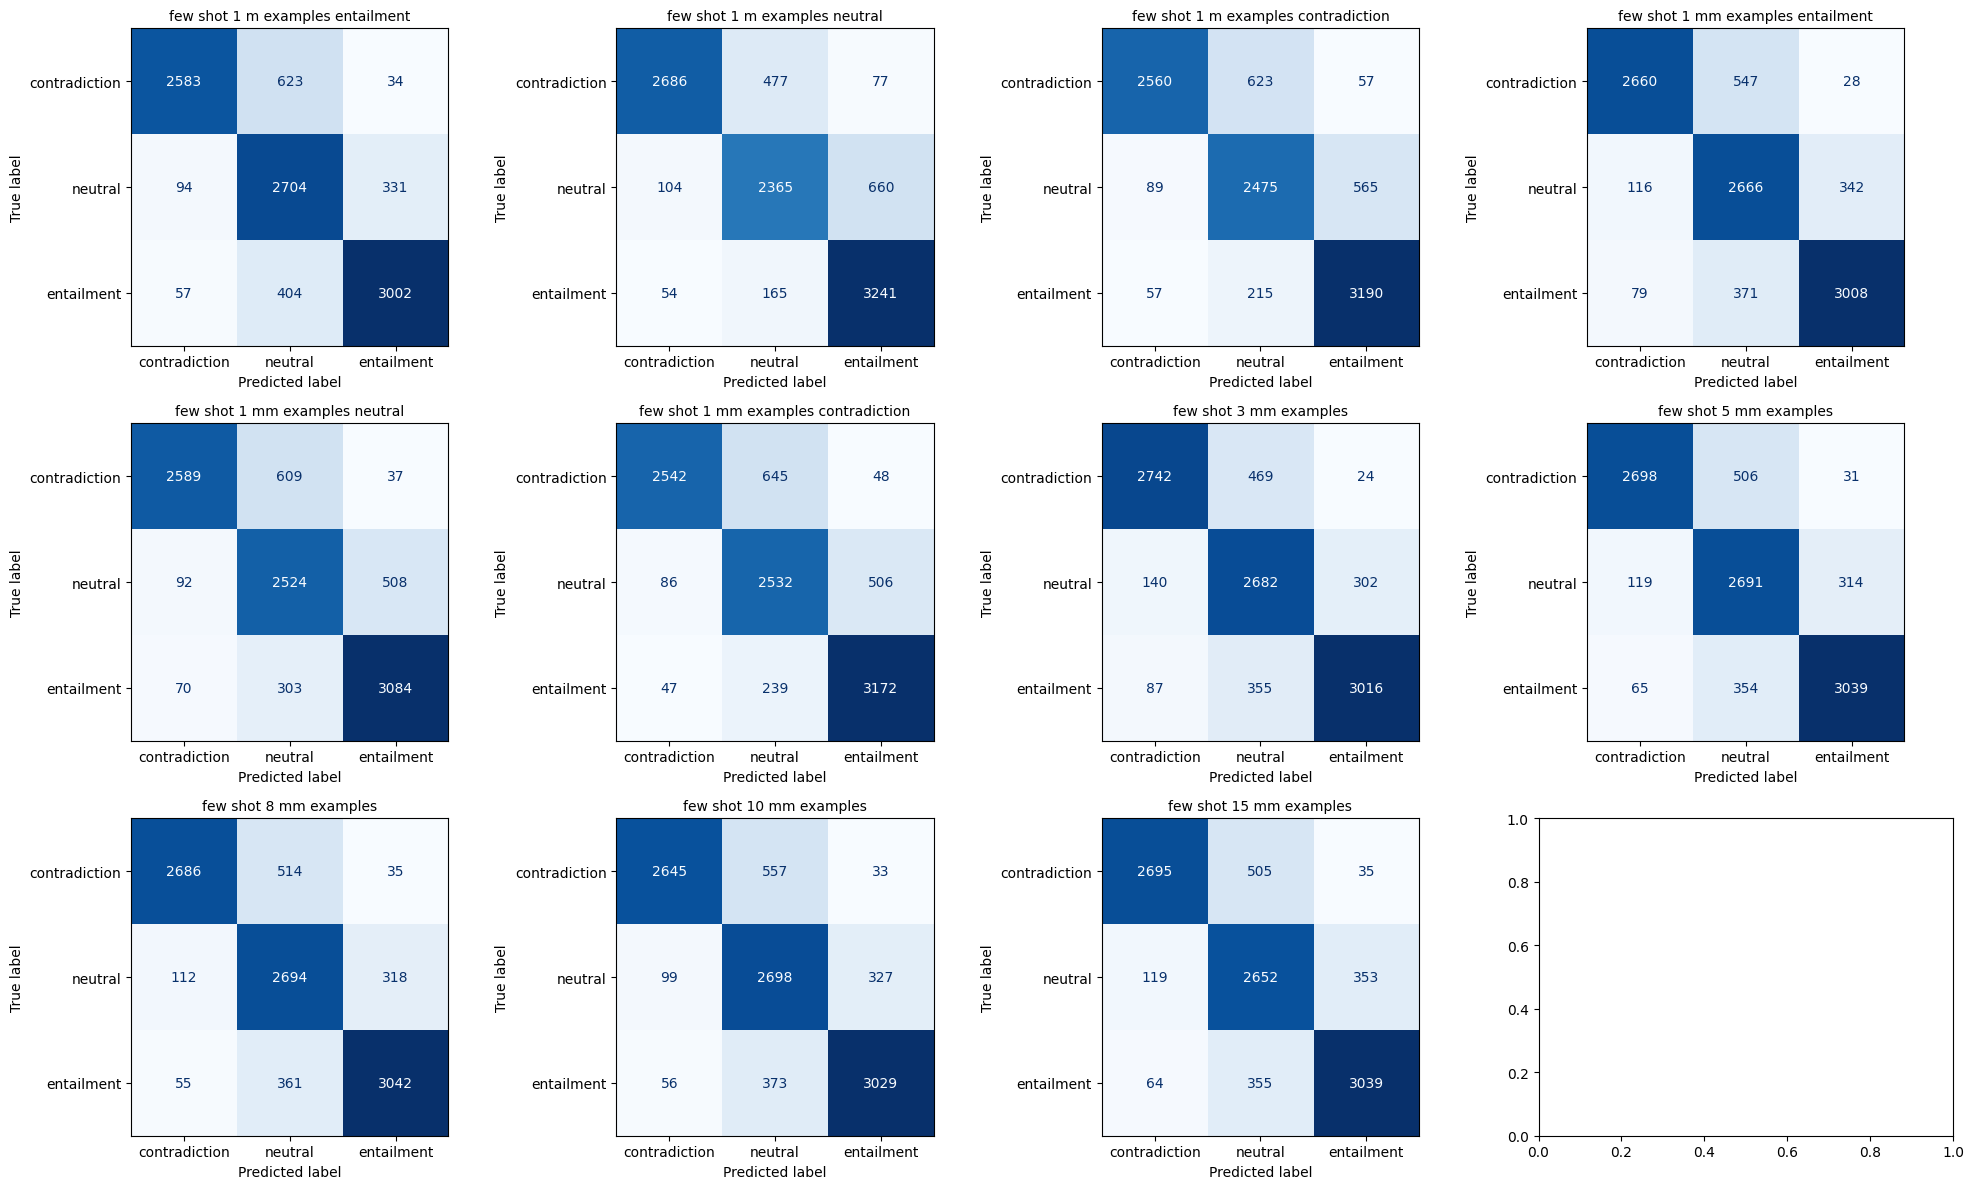

In [9]:
import matplotlib.pyplot as plt

training_modes = [
    # 'zero shot chat template',
    'few shot 1 m examples entailment',
    'few shot 1 m examples neutral',
    'few shot 1 m examples contradiction',
    'few shot 1 mm examples entailment',
    'few shot 1 mm examples neutral',
    'few shot 1 mm examples contradiction',
    'few shot 3 mm examples',
    'few shot 5 mm examples',
    'few shot 8 mm examples',
    'few shot 10 mm examples',
    'few shot 15 mm examples'    
]

fig, axes = plt.subplots(3, 4, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

idx = 0
for mode in training_modes:
    global_params = {
            'dataset_type': 'mnli_mm',
            'quantization': 'full',
            'training_mode': mode,
            'model_id': 'google/flan-t5-xl'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

    idx += 1


plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
labels = [
    # "0 examples",
    "1 m example (entailment)",
    "1 m example (neutral)",
    "1 m example (contradiction)",
    "1 mm example (entailment)",
    "1 mm example (neutral)",
    "1 mm example (contradiction)",
    "3 mm examples",
    "5 mm examples",
    "8 mm examples",
    "10 mm examples",
    "15 mm examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
    "F1": f1s,
    "MCC": mccs,
    "Kappa": kappas},
    index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
1 m example (entailment),0.8431,0.8537,0.8428,0.8440,0.7685,0.7647
1 m example (neutral),0.8434,0.6364,0.6302,0.6312,0.7670,0.7644
1 m example (contradiction),0.8366,0.6325,0.6256,0.6266,0.7570,0.7544
1 mm example (entailment),0.8489,0.8553,0.8485,0.8495,0.7756,0.7734
1 mm example (neutral),0.8350,0.6314,0.6250,0.6262,0.7544,0.7522
1 mm example (contradiction),0.8400,0.8476,0.8379,0.8392,0.7624,0.7596
3 mm examples,0.8597,0.8637,0.8594,0.8600,0.7911,0.7896
5 mm examples,0.8585,0.8640,0.8581,0.8589,0.7897,0.7878
8 mm examples,0.8579,0.8641,0.8574,0.8584,0.7890,0.7869
10 mm examples,0.8528,0.8607,0.8524,0.8535,0.7820,0.7793
